# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

c:\Users\kesha\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

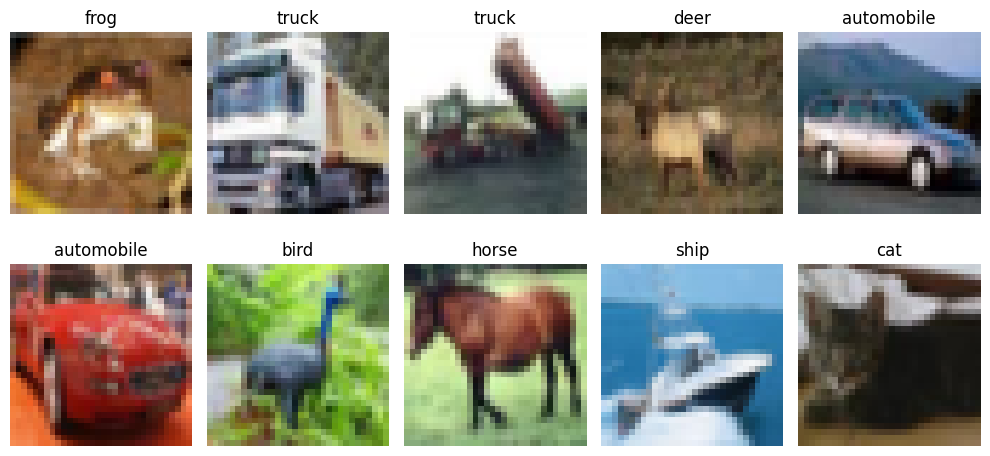

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

c:\Users\kesha\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.2697 - loss: 1.9992 - val_accuracy: 0.3408 - val_loss: 1.8563
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3116 - loss: 1.8766 - val_accuracy: 0.3540 - val_loss: 1.8057
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3312 - loss: 1.8287 - val_accuracy: 0.3630 - val_loss: 1.7778
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3426 - loss: 1.8010 - val_accuracy: 0.3770 - val_loss: 1.7460
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.3511 - loss: 1.7766 - val_accuracy: 0.3816 - val_loss: 1.7360
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3663 - loss: 1.7509 - val_accuracy: 0.3840 - val_loss: 1.7214
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.3729 - loss: 1.7324 - val_accuracy: 0.3900 - val_loss: 1.7015
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3747 - loss: 1.7182 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4230 - loss: 1.6444
ANN Test Accuracy: 0.4230000078678131


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

c:\Users\kesha\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 66ms/step - accuracy: 0.4666 - loss: 1.4943 - val_accuracy: 0.5558 - val_loss: 1.2713
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.6078 - loss: 1.1278 - val_accuracy: 0.5812 - val_loss: 1.2027
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.6678 - loss: 0.9532 - val_accuracy: 0.6286 - val_loss: 1.1143
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.7082 - loss: 0.8357 - val_accuracy: 0.6830 - val_loss: 0.9477
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.7447 - loss: 0.7337 - val_accuracy: 0.7028 - val_loss: 0.8609
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 70ms/step - accuracy: 0.7686 - loss: 0.6604 - val_accuracy: 0.7018 - val_loss: 0.8768
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 65ms/step - accuracy: 0.7920 - loss: 0.5948 - val_accuracy: 0.7054 - val_loss: 0.9171
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.8100 - loss: 0.5434 - 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7204 - loss: 0.9078
CNN Test Accuracy: 0.7203999757766724


## 📈 Compare Learning Curves

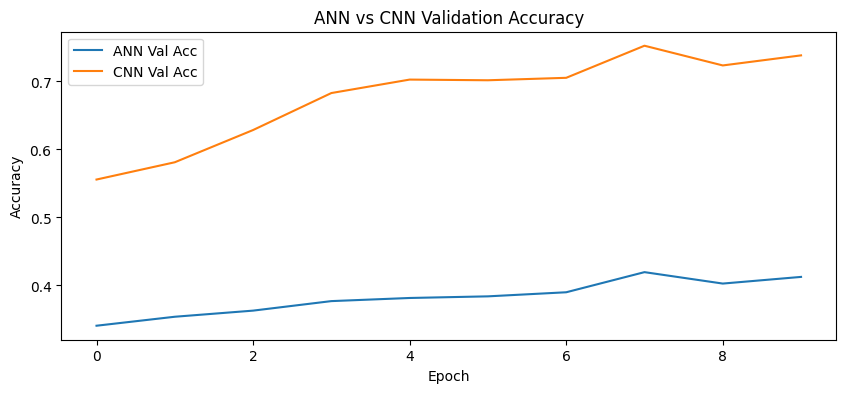

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.3836 - loss: 1.6936 - val_accuracy: 0.4988 - val_loss: 1.3819
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.4811 - loss: 1.4466 - val_accuracy: 0.5414 - val_loss: 1.2568
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step - accuracy: 0.5145 - loss: 1.3612 - val_accuracy: 0.6060 - val_loss: 1.1313
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step - accuracy: 0.5400 - loss: 1.2951 - val_accuracy: 0.6172 - val_loss: 1.0694
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 54s 38ms/step - accuracy: 0.5602 - loss: 1.2460 - val_accuracy: 0.6300 - val_loss: 1.0431
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step - accuracy: 0.5676 - loss: 1.2206 - val_accuracy: 0.6166 - val_loss: 1.0840
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - accuracy: 0.5808 - loss: 1.1904 - val_accuracy: 0.6262 - val_loss: 1.0476
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 55s 39ms/step - accuracy: 0.5870 -

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4230
1,CNN,0.7204


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

### Task 1: Increase ANN layers and observe performance

In [12]:
ann_model_deeper = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_deeper.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Deeper ANN...")
ann_deeper_history = ann_model_deeper.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_deeper_test_loss, ann_deeper_test_acc = ann_model_deeper.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:", ann_deeper_test_acc)

c:\Users\kesha\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Deeper ANN...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 39ms/step - accuracy: 0.2364 - loss: 2.0478 - val_accuracy: 0.3138 - val_loss: 1.9070
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.2902 - loss: 1.9207 - val_accuracy: 0.3236 - val_loss: 1.9038
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.3112 - loss: 1.8692 - val_accuracy: 0.3322 - val_loss: 1.8475
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.3250 - loss: 1.8476 - val_accuracy: 0.3516 - val_loss: 1.8146
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.3362 - loss: 1.8148 - val_accuracy: 0.3612 - val_loss: 1.8113
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.3430 - loss: 1.7996 - val_accuracy: 0.3858 - val_loss: 1.7539
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.3511 - loss: 1.7756 - val_accuracy: 0.3940 - val_loss: 1.7577
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0

### Task 2: Change CNN filters from 32→64→128

In [13]:
cnn_scaled_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_scaled_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

c:\Users\kesha\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Task 3 & 4: Increase epochs to 20 and Add EarlyStopping

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("Training Scaled CNN for 20 epochs with EarlyStopping...")
cnn_scaled_history = cnn_scaled_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

cnn_scaled_test_loss, cnn_scaled_test_acc = cnn_scaled_model.evaluate(x_test_norm, y_test)
print("Scaled CNN Test Accuracy:", cnn_scaled_test_acc)

Training Scaled CNN for 20 epochs with EarlyStopping...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 83ms/step - accuracy: 0.4403 - loss: 1.5691 - val_accuracy: 0.5798 - val_loss: 1.1686
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.5914 - loss: 1.1547 - val_accuracy: 0.3520 - val_loss: 2.2767
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.6626 - loss: 0.9649 - val_accuracy: 0.6516 - val_loss: 1.0314
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 83ms/step - accuracy: 0.7018 - loss: 0.8490 - val_accuracy: 0.7064 - val_loss: 0.8294
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 83ms/step - accuracy: 0.7335 - loss: 0.7630 - val_accuracy: 0.6744 - val_loss: 0.9743
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 82ms/step - accuracy: 0.7567 - loss: 0.6915 - val_accuracy: 0.6604 - val_loss: 1.0782
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 82ms/step - accuracy: 0.7819 - loss: 0.6213 - val_accuracy: 0.6128 - val_loss: 1.3637
Epoch 7: early stopping
Restoring 

### Task 5: Add data augmentation training

In [15]:
print("Training Augmented CNN for 20 epochs with EarlyStopping...")
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

Training Augmented CNN for 20 epochs with EarlyStopping...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.6176 - loss: 1.0819 - val_accuracy: 0.6526 - val_loss: 0.9821
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.6230 - loss: 1.0746 - val_accuracy: 0.6592 - val_loss: 0.9706
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.6258 - loss: 1.0646 - val_accuracy: 0.6774 - val_loss: 0.9029
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6522 - loss: 1.0011
Augmented CNN Test Accuracy: 0.6521999835968018


### Final Output Comparison Dataframe

In [16]:
final_comparison = pd.DataFrame({
    "Model": ["ANN (Baseline)", "ANN (Deeper)", "CNN (Baseline)", "CNN (Scaled + ES)", "CNN (Augmented + ES)"],
    "Test Accuracy": [ann_test_acc, ann_deeper_test_acc, cnn_test_acc, cnn_scaled_test_acc, aug_test_acc]
})
final_comparison

,Model,Test Accuracy
0,ANN (Baseline),0.4230
1,ANN (Deeper),0.4003
2,CNN (Baseline),0.7204
3,CNN (Scaled + ES),0.6885
4,CNN (Augmented + ES),0.6522


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**